## Этап 1 - Импорт библиотек и базовые константы

На этом этапе мы:
1. подключаем необходимые библиотеки
2. фиксируем путь к parquet-файлу
3. задаем параметры лучшей модели CatBoost, найденные на кросс-валидации

---

Важно:
- мы обучаем финальную модель только на объектах, где целевая высота действительно наблюдалась (target_height_is_observed == 1)
- затем применяем модель ко всему parquet, чтобы заполнить пропуски
- для стабильности воспроизводимости используем тот же RANDOM_STATE

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from shapely import wkb

In [2]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold

In [4]:
DATA_PATH = Path("../data/interim/merged_buildings_by_geometry.parquet") # Путь к исходному файлу
OUTPUT_PATH = Path("../data/interim/merged_buildings_filled_with_catboost.parquet") # Путь к выходному файлу

RANDOM_STATE = 42
GRID_SIZE = 1000
N_SPLITS = 5

# Параметры, которые мы определили на моменте выбора лучшей модели 
BEST_CB_PARAMS = {
    "iterations": 300,
    "learning_rate": 0.05,
    "depth": 6,
    "l2_leaf_reg": 3,
    "min_data_in_leaf": 10,
}

## Этап 2 - Список нужных колонок и служебные функции

Здесь мы:
- описываем столбцы, которые нужны для обучения и заполнения;
- повторно определяем функции для работы с геометрией, пространственными группами и признаками соседей;
- добавляем вспомогательные функции для метрик и для определения категориальных признаков под CatBoost.

In [5]:
main_cols = [
    "component_id",
    "match_type",
    "match_confidence",
    "geometry_source",

    "target_height",
    "target_height_is_observed",
    "target_height_source",
    "target_height_source_detail",
    "target_height_reliability",

    "n_a",
    "n_b",
    "uids_a",
    "uids_b",

    "n_edges_ab",
    "max_iou",
    "mean_iou",
    "max_overlap_a",
    "max_overlap_b",
    "min_dist_m",

    "sum_area_a",
    "sum_area_b",
    "union_area_a",
    "union_area_b",
    "union_area_all",

    "n_b_with_height",
    "median_height_b",
    "median_stairs_b",
    "median_avg_floor_height_b",
    "mode_purpose_b",

    "n_neighbors_50m",
    "n_neighbors_obs_height_50m",
    "neighbor_height_mean_50m",
    "neighbor_height_median_50m",
    "neighbor_height_min_50m",
    "neighbor_height_max_50m",
    "neighbor_height_std_50m",
    "neighbor_height_q25_50m",
    "neighbor_height_q75_50m",

    "n_neighbors_100m",
    "n_neighbors_obs_height_100m",
    "neighbor_height_mean_100m",
    "neighbor_height_median_100m",
    "neighbor_height_min_100m",
    "neighbor_height_max_100m",
    "neighbor_height_std_100m",
    "neighbor_height_q25_100m",
    "neighbor_height_q75_100m",

    "rep_geometry",
]

drop_match_metric_cols = [
    "max_iou",
    "mean_iou",
    "max_overlap_a",
    "max_overlap_b",
    "min_dist_m",
]

best_feature_cols = [
    "match_type",
    "match_confidence",
    "geometry_source",
    "target_height_reliability",
    "n_a",
    "n_b",
    "n_edges_ab",
    "sum_area_a",
    "sum_area_b",
    "union_area_a",
    "union_area_b",
    "union_area_all",
    "n_b_with_height",
    "median_height_b",
    "median_stairs_b",
    "median_avg_floor_height_b",
    "mode_purpose_b",

    "n_neighbors_50m",
    "n_neighbors_obs_height_50m",
    "neighbor_height_mean_50m",
    "neighbor_height_median_50m",
    "neighbor_height_min_50m",
    "neighbor_height_max_50m",
    "neighbor_height_std_50m",
    "neighbor_height_q25_50m",
    "neighbor_height_q75_50m",

    "n_neighbors_100m",
    "n_neighbors_obs_height_100m",
    "neighbor_height_mean_100m",
    "neighbor_height_median_100m",
    "neighbor_height_min_100m",
    "neighbor_height_max_100m",
    "neighbor_height_std_100m",
    "neighbor_height_q25_100m",
    "neighbor_height_q75_100m",

    "has_neighbor_height_mean_50m",
    "has_neighbor_height_median_50m",
    "has_neighbor_height_min_50m",
    "has_neighbor_height_max_50m",
    "has_neighbor_height_std_50m",
    "has_neighbor_height_q25_50m",
    "has_neighbor_height_q75_50m",

    "has_neighbor_height_mean_100m",
    "has_neighbor_height_median_100m",
    "has_neighbor_height_min_100m",
    "has_neighbor_height_max_100m",
    "has_neighbor_height_std_100m",
    "has_neighbor_height_q25_100m",
    "has_neighbor_height_q75_100m",
]


In [6]:
def load_wkb_geometry(value):
    if value is None or pd.isna(value):
        return None

    if isinstance(value, memoryview):
        value = value.tobytes()
    elif isinstance(value, bytearray):
        value = bytes(value)

    return wkb.loads(value)

In [7]:
def build_spatial_groups(df, geom_col="rep_geometry", grid_size=1000):
    geoms = df[geom_col].apply(load_wkb_geometry)
    centroids = geoms.apply(lambda g: g.centroid if g is not None else None)

    x = centroids.apply(lambda c: c.x if c is not None else np.nan)
    y = centroids.apply(lambda c: c.y if c is not None else np.nan)

    grid_x = np.floor(x / grid_size).astype("Int64")
    grid_y = np.floor(y / grid_size).astype("Int64")

    groups = grid_x.astype(str) + "_" + grid_y.astype(str)
    return groups, x, y

In [8]:
def add_neighbor_missing_indicators(df):
    df = df.copy()

    neighbor_stat_cols = [
        c for c in df.columns
        if c.startswith("neighbor_height_")
    ]

    for col in neighbor_stat_cols:
        ind_col = f"has_{col}"
        df[ind_col] = df[col].notna().astype(int)
        df[col] = df[col].fillna(0)

    return df

In [9]:
def compute_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "rmse": rmse,
        "mae": mae,
        "mse": mse,
        "r2": r2,
    }

In [10]:
def get_catboost_feature_info(X):
    categorical_cols = X.select_dtypes(
        include=["object", "category", "string"]
    ).columns.tolist()
    cat_features = [X.columns.get_loc(col) for col in categorical_cols]
    return categorical_cols, cat_features

In [11]:
def prepare_catboost_matrix(X):
    X = X.copy()
    categorical_cols, cat_features = get_catboost_feature_info(X)

    for col in categorical_cols:
        X[col] = X[col].astype("string").fillna("missing")

    return X, categorical_cols, cat_features

In [12]:
def build_catboost_model(cb_params):
    model = CatBoostRegressor(
        random_seed=RANDOM_STATE,
        loss_function="RMSE",
        eval_metric="RMSE",
        verbose=0,
        thread_count=-1,
        **cb_params,
    )
    return model

## Этап 3 - загрзка файла и подготовка полного DataFrame 

Здесь мы подготавливаем единый датасет для дальнейшей работы:
- читаем parquet
- оставляем нужные колонки
- удаляем метрики, которые решили не использовать в модели
- строим индикаторы пропусков для neighbor-статистик
- строим пространственные группы по центроидам геометрий

---

На выходе получаем:
- df_all      : полный датафрейм для последующего заполнения высоты;
- spatial_group, centroid_x, centroid_y : служебные поля для spatial CV.

In [13]:
df_all = pd.read_parquet(DATA_PATH)
df_all = df_all[main_cols].copy()

df_all = df_all.drop(columns=drop_match_metric_cols)
df_all = add_neighbor_missing_indicators(df_all)

df_all["spatial_group"], df_all["centroid_x"], df_all["centroid_y"] = build_spatial_groups(
    df_all,
    geom_col="rep_geometry",
    grid_size=GRID_SIZE,
)

print("Форма полного датасета:", df_all.shape)
print(df_all[["target_height", "target_height_is_observed", "spatial_group"]].head())

Форма полного датасета: (139649, 60)
   target_height  target_height_is_observed spatial_group
0            4.5                          1      673_6635
1            4.5                          1      673_6635
2           60.0                          1      677_6640
3            NaN                          0      677_6654
4            NaN                          0      677_6654


## Этап 4 - Выделение обучающей выборки и выборки для заполнения пропусков

На этом шаге мы делим данные на две логические части:

**train_df**:
- объекты, у которых высота наблюдалась и может использоваться как истинная целевая переменная при обучении

**pred_df:**
- объекты, у которых высота отсутствует или не является наблюдаемой, и для которых модель должна выдать прогноз.

In [14]:
train_df = df_all[df_all["target_height_is_observed"] == 1].copy()
train_cv_df = train_df[train_df["spatial_group"].notna()].copy()

pred_df = df_all[
    (df_all["target_height_is_observed"] != 1) | (df_all["target_height"].isna())
].copy()

print("Объектов с наблюдаемой высотой:", len(train_df))
print("Объектов для spatial CV:", len(train_cv_df))
print("Объектов для заполнения:", len(pred_df))

Объектов с наблюдаемой высотой: 101563
Объектов для spatial CV: 101563
Объектов для заполнения: 38086


## Этап 5 - Проверка стабильности лучшей модели на spatial CV

Перед финальным дообучением полезно еще раз посмотреть, насколько стабильно работает лучшая конфигурация по пространственным фолдам.

Здесь мы:
- берем только наблюдаемые высоты
- делаем GroupKFold по spatial_group
- на каждом фолде обучаем CatBoost с лучшими параметрами
- сохраняем метрики по каждому фолду
- собираем OOF-предсказания для общей оценки

Это позволяет понять:
- насколько стабилен RMSE между фолдами
- нет ли сильного провала на отдельных пространственных зонах
- насколько реалистично ожидать хорошее качество при заполнении пропусков

In [15]:
X_cv_raw = train_cv_df[best_feature_cols].reset_index(drop=True)
y_cv = train_cv_df["target_height"].reset_index(drop=True)
groups_cv = train_cv_df["spatial_group"].reset_index(drop=True)

X_cv, categorical_cols, cat_features = prepare_catboost_matrix(X_cv_raw)

cv = GroupKFold(n_splits=N_SPLITS)

fold_rows = []
oof_pred = np.full(len(X_cv), np.nan, dtype=float)

for fold, (train_idx, test_idx) in enumerate(cv.split(X_cv, y_cv, groups_cv), start=1):
    X_train = X_cv.iloc[train_idx].copy()
    X_test = X_cv.iloc[test_idx].copy()
    y_train = y_cv.iloc[train_idx]
    y_test = y_cv.iloc[test_idx]

    model_fold = build_catboost_model(BEST_CB_PARAMS)
    model_fold.fit(X_train, y_train, cat_features=cat_features)

    pred = model_fold.predict(X_test)
    oof_pred[test_idx] = pred

    metrics = compute_metrics(y_test, pred)
    metrics["fold"] = fold
    metrics["n_train"] = len(train_idx)
    metrics["n_test"] = len(test_idx)
    fold_rows.append(metrics)

folds_df = pd.DataFrame(fold_rows)
folds_df

,rmse,mae,mse,r2,fold,n_train,n_test
0,0.262313,0.072855,0.068808,0.999410,1,81250,20313
1,2.683570,0.059621,7.201549,0.947378,2,81250,20313
2,0.183837,0.069360,0.033796,0.999674,3,81250,20313
3,0.161031,0.077775,0.025931,0.999745,4,81251,20312
4,0.143328,0.064117,0.020543,0.999768,5,81251,20312


## Этап 6 - Сводка по стабильности модели

Здесь мы смотрим:
- метрики по каждому фолду
- средние значения
- стандартное отклонение, особенно для RMSE и MAE

In [16]:
cv_summary = pd.DataFrame({
    "metric": ["rmse", "mae", "mse", "r2"],
    "mean": [
        folds_df["rmse"].mean(),
        folds_df["mae"].mean(),
        folds_df["mse"].mean(),
        folds_df["r2"].mean(),
    ],
    "std": [
        folds_df["rmse"].std(),
        folds_df["mae"].std(),
        folds_df["mse"].std(),
        folds_df["r2"].std(),
    ],
})

print("Метрики по фолдам:")
display(folds_df)

print("\nСводка по стабильности:")
display(cv_summary)

overall_oof_metrics = compute_metrics(y_cv, oof_pred)
print("\nOOF-метрики по всем объектам вместе:")
print(overall_oof_metrics)

Метрики по фолдам:


,rmse,mae,mse,r2,fold,n_train,n_test
0,0.262313,0.072855,0.068808,0.999410,1,81250,20313
1,2.683570,0.059621,7.201549,0.947378,2,81250,20313
2,0.183837,0.069360,0.033796,0.999674,3,81250,20313
3,0.161031,0.077775,0.025931,0.999745,4,81251,20312
4,0.143328,0.064117,0.020543,0.999768,5,81251,20312



Сводка по стабильности:


,metric,mean,std
0,rmse,0.686816,1.117144
1,mae,0.068745,0.007132
2,mse,1.470125,3.204018
3,r2,0.989195,0.023377



OOF-метрики по всем объектам вместе:
{'rmse': np.float64(1.2124990327151857), 'mae': 0.06874535691192647, 'mse': 1.4701539043352607, 'r2': 0.9865943287827699}


## Этап 7 - Визуальная проверка стабильности по фолдам

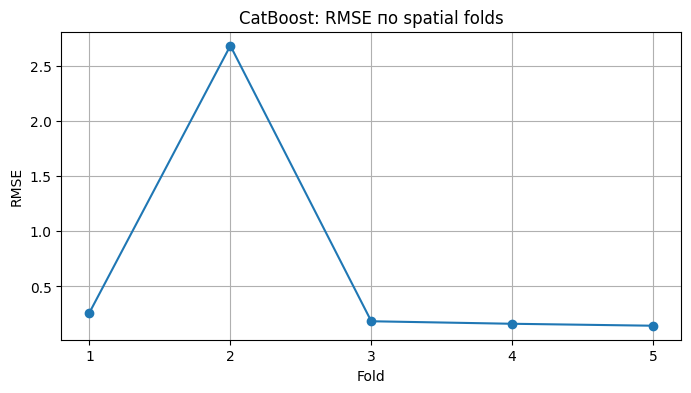

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(folds_df["fold"], folds_df["rmse"], marker="o")
plt.xticks(folds_df["fold"])
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title("CatBoost: RMSE по spatial folds")
plt.grid(True)
plt.show()

Модель CatBoost показала высокое среднее качество, но spatial CV выявила один проблемный фолд. Это объясняется пространственной неоднородностью данных: в отдельных зонах структура застройки и информативность ключевых признаков отличаются от обучающей выборки, поэтому ошибка локально возрастает.

Такое поведение является ожидаемым для геоданных. Spatial cross-validation устроена более строго, чем обычная случайная валидация: модель обучается на одних пространственных зонах и проверяется на других. Если один из фолдов содержит участок застройки, существенно отличающийся по структуре от остальных — например, по типу зданий, плотности, качеству исходных источников или доступности соседних объектов с известной высотой, — ошибка на нем может существенно возрастать. Иными словами, модель сталкивается не просто с новыми объектами, а с новой локальной пространственной конфигурацией, которая хуже представлена в обучающих данных.

## Этап 8 - Обучение финальной модели на всех наблюдаемых высотах

После проверки стабильности мы обучаем финальную модель уже на всех объектах с наблюдаемой высотой.

In [18]:
X_train_full_raw = train_df[best_feature_cols].copy()
y_train_full = train_df["target_height"].copy()

X_train_full, categorical_cols_full, cat_features_full = prepare_catboost_matrix(X_train_full_raw)

final_cb_model = build_catboost_model(BEST_CB_PARAMS)
final_cb_model.fit(X_train_full, y_train_full, cat_features=cat_features_full)

print("Финальная модель обучена.")

Финальная модель обучена.


## Этап 9 - Анализ важности признаков

Теперь смотрим, какие признаки сильнее всего влияют на прогноз высоты.

Для CatBoost используем встроенную importance.
Это даст нам:
- список наиболее важных признаков
- материал для интерпретации результатов
- знание, какие факторы реально определяют высоту.

In [19]:
feature_importance_df = pd.DataFrame({
    "feature": X_train_full.columns,
    "importance": final_cb_model.get_feature_importance(),
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(feature_importance_df.head(20))

,feature,importance
0,median_height_b,88.869106
1,median_stairs_b,10.195502
2,median_avg_floor_height_b,0.392773
3,n_neighbors_obs_height_50m,0.092469
4,has_neighbor_height_std_50m,0.091668
5,neighbor_height_mean_50m,0.054759
6,neighbor_height_q75_100m,0.052794
7,neighbor_height_q75_50m,0.044411
8,sum_area_b,0.039496
9,union_area_a,0.036594


## Этап 10 - Визуализация топа важных признаков

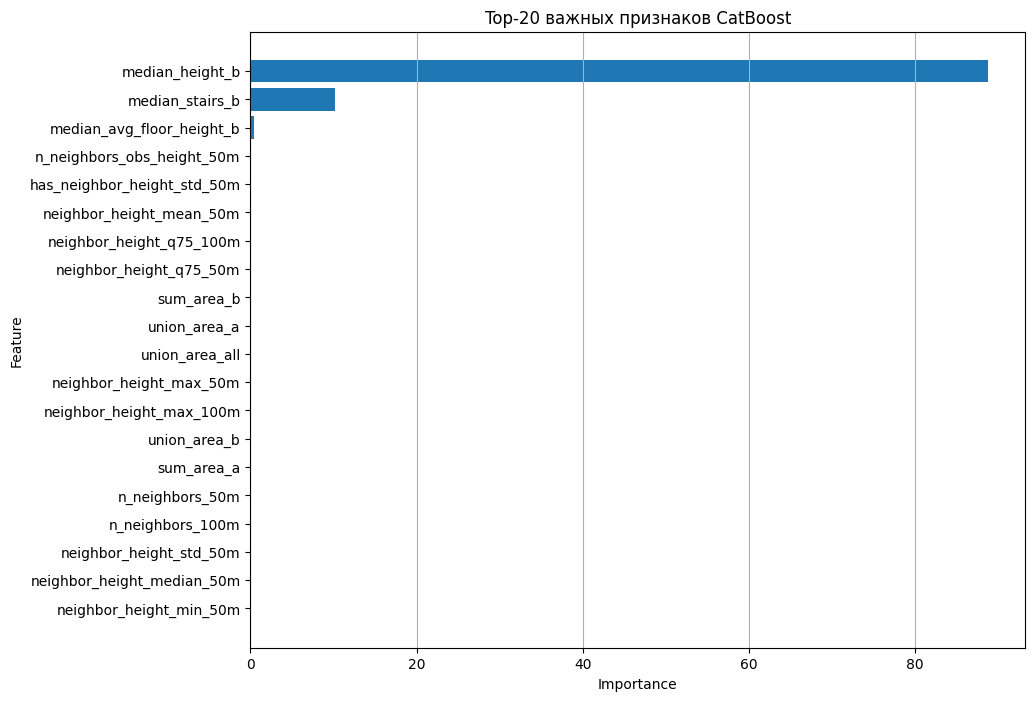

In [20]:
top_n = 20
top_importance = feature_importance_df.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Top-{top_n} важных признаков CatBoost")
plt.grid(True, axis="x")
plt.show()

## Этап 11 - Прогноз высоты для объектов с пропусками

Теперь применяем финальную модель к тем объектам, где высота отсутствует или не была наблюдаемой.

In [21]:
X_pred_raw = pred_df[best_feature_cols].copy()
X_pred, _, _ = prepare_catboost_matrix(X_pred_raw)

pred_height = final_cb_model.predict(X_pred)

pred_df = pred_df.copy()
pred_df["target_height_predicted"] = pred_height

pred_df[[
    "component_id",
    "target_height",
    "target_height_is_observed",
    "target_height_predicted"
]].head()

,component_id,target_height,target_height_is_observed,target_height_predicted
3,4,NaN,0,3.423235
4,5,NaN,0,3.423124
7,8,NaN,0,3.465983
8,9,NaN,0,3.460535
9,10,NaN,0,3.470120


## Этап 12 - Сборка итогового датафрейма с заполненной высотой

In [22]:
df_result = df_all.copy()

pred_map = pred_df.set_index("component_id")["target_height_predicted"]

df_result["target_height_predicted"] = df_result["component_id"].map(pred_map)

df_result["target_height_filled"] = df_result["target_height"]
mask_need_fill = df_result["target_height_filled"].isna() | (df_result["target_height_is_observed"] != 1)

df_result.loc[mask_need_fill, "target_height_filled"] = df_result.loc[mask_need_fill, "target_height_predicted"]

df_result["target_height_was_predicted"] = mask_need_fill.astype(int)
df_result["target_height_fill_source"] = np.where(
    df_result["target_height_was_predicted"] == 1,
    "catboost",
    "observed"
)

df_result[[
    "component_id",
    "target_height",
    "target_height_predicted",
    "target_height_filled",
    "target_height_fill_source",
    "target_height_was_predicted",
]].head(10)

,component_id,target_height,target_height_predicted,target_height_filled,target_height_fill_source,target_height_was_predicted
0,1,4.50,NaN,4.500000,observed,0
1,2,4.50,NaN,4.500000,observed,0
2,3,60.00,NaN,60.000000,observed,0
3,4,NaN,3.423235,3.423235,catboost,1
4,5,NaN,3.423124,3.423124,catboost,1
5,6,48.00,NaN,48.000000,observed,0
6,7,68.25,NaN,68.250000,observed,0
7,8,NaN,3.465983,3.465983,catboost,1
8,9,NaN,3.460535,3.460535,catboost,1
9,10,NaN,3.470120,3.470120,catboost,1


## Этап 13 - Проверка результатов заполнения

In [23]:
print("Всего объектов:", len(df_result))
print("Предсказанных высот:", int(df_result["target_height_was_predicted"].sum()))
print("Пропусков в итоговой высоте:", int(df_result["target_height_filled"].isna().sum()))

print("\nСтатистика по предсказанным высотам:")
display(
    df_result.loc[df_result["target_height_was_predicted"] == 1, "target_height_filled"].describe()
)

Всего объектов: 139649
Предсказанных высот: 38086
Пропусков в итоговой высоте: 0

Статистика по предсказанным высотам:


count    38086.000000
mean         3.437084
std          0.033575
min          3.079522
25%          3.423136
50%          3.430899
75%          3.461058
max          3.865614
Name: target_height_filled, dtype: float64

## Этап 14 - Сохранение итогового датасета

In [24]:
df_result.to_parquet(OUTPUT_PATH, index=False)
print(f"Итоговый parquet сохранен: {OUTPUT_PATH}")

Итоговый parquet сохранен: merged_buildings_filled_with_catboost.parquet
